In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# LLM 선언

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")  # 답변이 잘 안나오는데는 mini 모델을 써서 그럴수도 있다. (원래 gpt-4o 사용)
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
# state 작성
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str  
    context:list 
    answer: str


graph_builder = StateGraph(AgentState)  

In [4]:
# prompt 가 필요하다
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to December 2024.
'real_estate_tax' contains information about real estate tax up to December 2024.
if you think the question is not related to either 'income_tax' or 'real_estate_tax';
you can route it to 'llm'.
"""

# from_template이 아닌, from_messages
# string 형태가 아닌 튜플 기반의 리스트가 들어간다. 
router_prompt = ChatPromptTemplate.from_messages([
    # system prompt -> openai 경우, developer로 롤이 바뀜 (랭체인에서는 system으로 그대로..)
    ("system", router_system_prompt),
    ("user", "{query}")
])

class Route(BaseModel):
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )

structured_router_llm = small_llm.with_structured_output(Route)

def router(state:AgentState):
    query = state['query']
    # router_chain = router_prompt | router_llm | StrOutputParser()

    # StrOutputParser 제거 -> [Input should be valid string...] -> type을 Route로 이미 정했는데, string으로 파싱하라고 하니까 에러 남 (pydantic 모델 형태로 바로 받도록)
    router_chain = router_prompt | structured_router_llm 

    route = router_chain.invoke({'query' : query})  # 반환 타입은 Route 
    # print(f'route response == {route}')
    print(f'route response == {route.target}')  

    # return {'answer' : route}
    return route.target  # return route 로만 한다면? unhashableType: 'Route' 에러와 함께 [target=='llm] 이렇게 나온다. target 오브젝트에 접근해서 target의 값만 반환하도록 해야 함.

In [5]:
from langchain_core.output_parsers import StrOutputParser


def call_llm(state: AgentState):
    query = state['query']
    llm_chain = small_llm | StrOutputParser()
    llm_answer = llm_chain.invoke(query)
    return {'answer' : llm_answer}

In [6]:
# 노드 추가

from income_tax_graph import graph as income_tax_agent
from real_estate_tax_graph import graph as real_estate_tax_agent


graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('real_estate_tax', real_estate_tax_agent)
graph_builder.add_node('llm', call_llm)

② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 제출하여야 한다는 경우에는 기준소득 중 거주자 본인이 된다(분산)과 제70조제2와 제74조에 따른 제료 및 제대법을 포함한다. 단, 차별제표청정인 그 업체를 남겨 제출한 경우로 그에 대하여 아니하다.<개정 2013. 1. 1.>
  ③ 제80조에 따른 수익과 관련의 경우에는 기초공제 중 거주자 본인이 된다(분산)과 그에 관한 적지사항을 분명히 한다.
[전문개정 2009. 12. 31.]
[제목개정 2014. 1. 1.]
제54조의2(공동사업에 대한 소득공제 등 특례) 제51조의3 또는 「조세특례제한법」에 따른 소득공제를 적용하거나 제59조의2에 따른 세액감면을 적용하는 경우 제54조제3항에 따라 공동사업자의 소득에 합산과세되는 특별세액거래의 지출․납입․투자 등의 금액이 있을 경우 주된 공동사업자의 소득에 합산과세되는 소득금액에 합산되어 주된 공동사업자의 합산과세세액은 공동사업소득액 또는 공동사업창출세액을 계산할 때 소득공제 또는 세액공제를 받을 수 있다. 
[개정 2014. 1. 1.]
[전문개정 2009. 12. 31.]
[제목개정 2014. 1. 1.]
제2절 세액의 계산 <개정 2009. 12. 31.>
제1관 세율 <개정 2009. 12. 31.>
제55조(세율) 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 "종합소득과세표준세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>
종합소득
┌───────────────┐
│ 과세표준의 6개 구간 │
├───────────────┤
│ 1,400만원 이하        │ 84만원  │
│ 1,400만원 초과        │ 84만원 + (5,000만원을 초과하는 금액의 24%)  │
│ 8,800만원 이하        │ 

d:\work\project\workspace\AI\langgraph-agent\real_estate_tax_graph.py:164: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search_tool = TavilySearchResults(


context == [{'title': '2026년 공시가격 18일 공개…"시세변동분만 반영" - 네이트 뉴스', 'url': 'https://news.nate.com/view/20260313n11631', 'content': '[̳ȴ]   ð  ̴ ۵ȴ. ð ȭ 69% ؿ .   \n   \n䱳δ  1 1  硤 ( 1585) ðݾȿ    ǰû   18Ϻ   6ϱ 20ϰ Ѵٰ 13 .   \n  \n  \n ô 4 30 ̴.   \n   \n ð 2026 ε   ȿ  ؿ  ȭ 69% ߴ.   \n   \nؿ  ȭ Ǹ鼭 ü и ݿ  ð  ̴.  \n  \ngoing@fnnews.com ְ   \n  \nCopyright ̳ȴ.    .  \n  \n[̳ȴ ִ]   \n  \n \'ǻ ȥӽ\'  "ݫ ..."   \n 70롤50 ü  ä ߰,     \n 20 "()  .." ī, Ҽ ǵ [...] 13. 28 "ε  "119 Ű ߿  39% \'\' ϶1\n  14. 29 ʵ Ǽҿ\'  缳\' 念ϵ ´ 66\n  15. 30 ѱ ߾! ϶10 [...] [[] Ƽɴ](//news.nate.com/rank/interest?sc=eco "ɴ")\n\n 1    1600,  ġŲ...\n 2 " ȾҴٰ Ѵ\u07b8 ߴ" ...\n 3 , 5   3õt \n 4 " 171% ͷ  "...\n 5 \'448049900\' 10 \ue866" ;...\n\n 6 Ｚ DX ӿ ڳ Ÿµ...\n 7 " \u07b6  ָ ٺ"...\n 8 \'12ƾ\' ѱ ־ĿǴ ̰...\n 9 30  "ߴ  ⸸ 300...\n 10 "   ȷ" ġ  ...\n\n\n\n̽ð ֿ䴺', 'score': 0.99899954, 'raw_content': '[NATE](//www.nate.com/?f=news) [](//news.nate.com/)\n\n* [](//sports.news.nate.com/)\n* [](//news.nate.com/ent/section?mid=e0100)\n* [](//

In [7]:
# 엣지 추가

from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax' : 'income_tax',
        'real_estate_tax' : 'real_estate_tax',
        'llm': 'llm'
    }
)

graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('real_estate_tax', END)
graph_builder.add_edge('llm', END)

In [8]:
graph= graph_builder.compile()

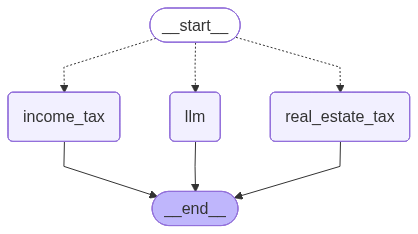

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))  


In [10]:
# initial_state

initial_state = {'query' : '소득세란 무엇인가요?'}
graph.invoke(initial_state)

route response == income_tax
context == [Document(id='2ed80c59-a561-462e-80d0-5fba7dd244df', metadata={'source': './docs/income_tax.txt'}, page_content='재산세에 관한 일반 수수료\n\n\n사레량 \n\n\n대통령령으로 정하는 소득· 소상공인 정보부의 해제신고\n\n\n다음 각 목의 어느 하나에 해당하는 인정요건(제15조부터 제17조까지의 규정되는 용역은 지속적인 일시적인 제효에 받는 대가\n  가. 고용관계에 있는 자에게 급여금 또는 강연료 등 대가를 받는 용역\n  나. 라디오·텔레비전방송을 통하여 선전·계몽 또는 연기 등의 일반적 실시하는 사항 등을 보수 또는 이와 유사한 성질의 대가를 받는 용역\n\n\n변호사, 공인회계사, 세무사, 건축사, 변리사, 그 밖에 전문적 지식 또는 특별한 기능을 가진 자가 지식 또는 기능을 활용하여 보수 또는 그 밖에 대가를 받거나 제공하는 용역\n\n\n단일계약, 제167조의 규정으로 저촉될 경우\n\n\n제20조제31항제2호나목 및 다목의 금액을 소득의 성격에도 불구하고 면역의법한 소득\n\n\n재직 중에 부여받은 주식매수선택권을 제외 후 행사하여 고용관계 없이 주식매수선택권을 부여받은 이익\n\n\n중검원 또는 대학의 교직원이 퇴직한 후 지급받는 직무별봉상금\n\n\n입금\n\n\n종교관련활동자 중 종교기관사 지속해는 등 종교관련종사자로서의 활동과 관련하여 대통령령으로 정하는 종교 단체로부터 받은 소득(이하 ‘종교관련소득’이라 한다)\n\n\n7차장사에 이용자 보도 및 관련 법률 제20조제1항에 따른 가장사사(이하 ‘가장사사’라 한다)를 양도하거나 대여함으로써 발생하는 소득(이하 ‘가장사산소득’이라 한다)'), Document(id='74f2b6e6-6465-4dcd-bf7c-7d7b53743bb4', metadata={'source': './docs/income_tax.txt'}, page_cont

{'query': '소득세란 무엇인가요?',
 'context': [Document(id='2ed80c59-a561-462e-80d0-5fba7dd244df', metadata={'source': './docs/income_tax.txt'}, page_content='재산세에 관한 일반 수수료\n\n\n사레량 \n\n\n대통령령으로 정하는 소득· 소상공인 정보부의 해제신고\n\n\n다음 각 목의 어느 하나에 해당하는 인정요건(제15조부터 제17조까지의 규정되는 용역은 지속적인 일시적인 제효에 받는 대가\n  가. 고용관계에 있는 자에게 급여금 또는 강연료 등 대가를 받는 용역\n  나. 라디오·텔레비전방송을 통하여 선전·계몽 또는 연기 등의 일반적 실시하는 사항 등을 보수 또는 이와 유사한 성질의 대가를 받는 용역\n\n\n변호사, 공인회계사, 세무사, 건축사, 변리사, 그 밖에 전문적 지식 또는 특별한 기능을 가진 자가 지식 또는 기능을 활용하여 보수 또는 그 밖에 대가를 받거나 제공하는 용역\n\n\n단일계약, 제167조의 규정으로 저촉될 경우\n\n\n제20조제31항제2호나목 및 다목의 금액을 소득의 성격에도 불구하고 면역의법한 소득\n\n\n재직 중에 부여받은 주식매수선택권을 제외 후 행사하여 고용관계 없이 주식매수선택권을 부여받은 이익\n\n\n중검원 또는 대학의 교직원이 퇴직한 후 지급받는 직무별봉상금\n\n\n입금\n\n\n종교관련활동자 중 종교기관사 지속해는 등 종교관련종사자로서의 활동과 관련하여 대통령령으로 정하는 종교 단체로부터 받은 소득(이하 ‘종교관련소득’이라 한다)\n\n\n7차장사에 이용자 보도 및 관련 법률 제20조제1항에 따른 가장사사(이하 ‘가장사사’라 한다)를 양도하거나 대여함으로써 발생하는 소득(이하 ‘가장사산소득’이라 한다)'),
  Document(id='74f2b6e6-6465-4dcd-bf7c-7d7b53743bb4', metadata={'source': './docs/income_tax.txt'}, page_conte

In [11]:
initial_state = {'query' : '집 15억은 세금을 얼마나 내나요'}
graph.invoke(initial_state)

route response == real_estate_tax
context == [{'title': '2026년 공시가격 18일 공개…"시세변동분만 반영" - 네이트 뉴스', 'url': 'https://news.nate.com/view/20260313n11631', 'content': '[̳ȴ]   ð  ̴ ۵ȴ. ð ȭ 69% ؿ .   \n   \n䱳δ  1 1  硤 ( 1585) ðݾȿ    ǰû   18Ϻ   6ϱ 20ϰ Ѵٰ 13 .   \n  \n  \n ô 4 30 ̴.   \n   \n ð 2026 ε   ȿ  ؿ  ȭ 69% ߴ.   \n   \nؿ  ȭ Ǹ鼭 ü и ݿ  ð  ̴.  \n  \ngoing@fnnews.com ְ   \n  \nCopyright ̳ȴ.    .  \n  \n[̳ȴ ִ]   \n  \n \'ǻ ȥӽ\'  "ݫ ..."   \n 70롤50 ü  ä ߰,     \n 20 "()  .." ī, Ҽ ǵ [...] 13. 28 "ε  "119 Ű ߿  39% \'\' ϶1\n  14. 29 ʵ Ǽҿ\'  缳\' 念ϵ ´ 66\n  15. 30 ѱ ߾! ϶10 [...] [[] Ƽɴ](//news.nate.com/rank/interest?sc=eco "ɴ")\n\n 1    1600,  ġŲ...\n 2 " ȾҴٰ Ѵ\u07b8 ߴ" ...\n 3 , 5   3õt \n 4 " 171% ͷ  "...\n 5 \'448049900\' 10 \ue866" ;...\n\n 6 Ｚ DX ӿ ڳ Ÿµ...\n 7 " \u07b6  ָ ٺ"...\n 8 \'12ƾ\' ѱ ־ĿǴ ̰...\n 9 30  "ߴ  ⸸ 300...\n 10 "   ȷ" ġ  ...\n\n\n\n̽ð ֿ䴺', 'score': 0.99899954, 'raw_content': '[NATE](//www.nate.com/?f=news) [](//news.nate.com/)\n\n* [](//sports.news.nate.com/)\n* [](//news.nate.c

{'query': '집 15억은 세금을 얼마나 내나요',
 'answer': '사용자가 소지한 주택이 2주택 이하라는 가정하에 종합부동산세를 계산하겠습니다.\n\n1. **공제금액 계산**: \n   - 공시가격: 15억 원 (1,500,000,000 원)\n   - 공제금액: 12억 원 (1,200,000,000 원)\n   - 과세표준 전 금액 계산:\n   \\[\n   \\text{과세표준 전 금액} = 1,500,000,000 - 1,200,000,000 = 300,000,000 \\text{원}\n   \\]\n\n2. **과세표준 계산**:\n   - 과세표준이 3억 원 이하이므로 해당하는 세율을 적용합니다:\n   \\[\n   \\text{Tax Base} = 0.005 \\times 300,000,000 = 1,500,000 \\text{원}\n   \\]\n\n3. **세금 계산**:\n   - 이제 과세표준에 대해 세율을 적용하여 세금을 계산합니다. 과세표준은 1,500,000원이므로, 세금을 구하는 과정은 다음과 같습니다:\n   - 1,500,000 원에 해당하는 세율은 0.5%입니다.\n   \\[\n   \\text{세금} = 1,500,000 \\times 0.005 = 7,500 \\text{원}\n   \\]\n\n따라서, 주택의 공시가격이 15억 원일 경우, 대략적으로 종합부동산세는 7,500원이 됩니다. 정확한 세금은 최종 세율에 따라 달라질 수 있으므로 해당 세율을 확인하는 것이 중요합니다. 여기서는 세율을 가정하여 계산하였습니다.'}

In [12]:
initial_state = {'query' : '떡볶이는 어디가 맛있나요?'}
graph.invoke(initial_state)

route response == llm


ValueError: Invalid input type <class 'dict'>. Must be a PromptValue, str, or list of BaseMessages.